In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.pyplot as plt
import scienceplots
import os
plt.style.use(['science', 'ieee'])
plt.rcParams['figure.dpi'] = 250

In [2]:
DIRECTIONS = [(1,0), (-1,0), (0,1), (0,-1), (1,-1), (-1,1)]

def neighbors(q, r):
    return [(q+dq, r+dr) for dq, dr in DIRECTIONS]

def n_max(N_i):
    N_i = int(round(N_i))
    if N_i <= 1:
        return 0.0
    cluster = {(0, 0)}
    frontier = set(neighbors(0, 0))
    while len(cluster) < N_i:
        def score(p):
            bonds = sum(1 for nb in neighbors(*p) if nb in cluster)
            dist = p[0]**2 + p[1]**2 + p[0]*p[1]
            return (bonds, -dist)
        best = max(frontier, key=score)
        cluster.add(best)
        frontier.discard(best)
        frontier.update(nb for nb in neighbors(*best) if nb not in cluster)
    E = sum(1 for p in cluster for nb in neighbors(*p) if nb in cluster) // 2
    return 2 * E / N_i

In [3]:
m = 6.0                      # exact for your torus/PBC geometry

rho = 0.1                    # your surface coverage
N_v = 1968
kappa = 20
N_i = rho * N_v               # number of inclusions
n_0 = rho * m
n_m = n_max(N_v)
print("n_0=",n_0)
print("n_m=",n_m)
base_dir = "/lustre/astro/semygind/Data/MembraneInclusion/ProteinClustering/FromEquilibrium/"
dK_list = np.array([20, 40, 80, 100, 400, 800, 1000, 4000, 8000, 10000, 20000])

def ProteinClustering(base_dir, rho=0.1,N_r=8):
    # n_from_your_data = measured n for a given frame (from your cluster-size histogram: 
    #   n = sum_S (S-1)/... — see note below)
    mean = []
    error = []
    for dK in dK_list:
        i1 = 1000
        delta_n= []
        for r in range(1,N_r+1):
            path = base_dir + f"/RHO{rho}/dK{dK}/rep{r}/AdriaAnalysis/dts.ana"
            #path = f"/lustre/astro/semygind/Data/MembraneInclusion/ProteinClustering/OnlyMembrane/RHO{rho}/dK{dK}/rep{r}/AdriaAnalysis/dts.ana"
            n = np.genfromtxt(path,skip_header=1,usecols=8)
            #print(n)
            #print(n_mean)
            delta_n_r = (np.mean(n[i1:]) - n_0) / (n_m - n_0)
            #print(delta_n_r)
            delta_n.append(delta_n_r)

        #print(delta_n)
        mean.append(np.mean(delta_n))
        error.append(np.std(delta_n)/np.sqrt(len(delta_n)-1))
    return mean, error



#print(mean, error)

n_0= 0.6000000000000001
n_m= 5.84349593495935


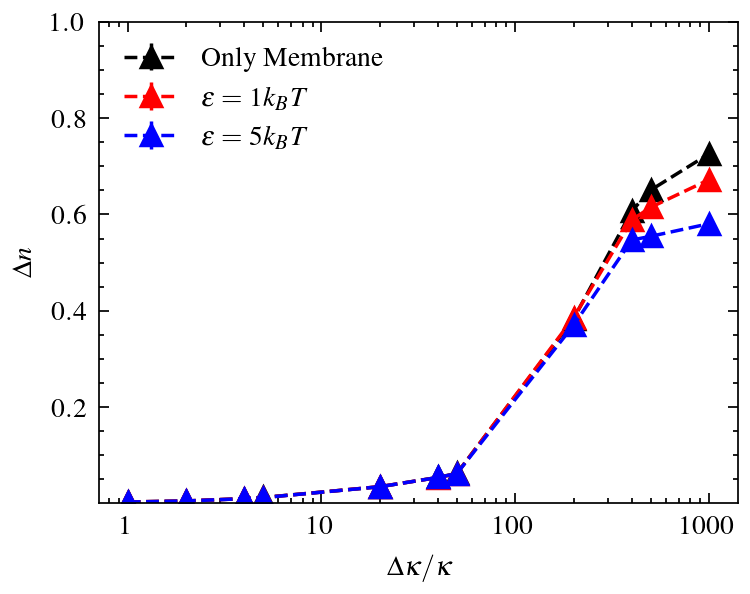

In [4]:
Simulation = base_dir + "OnlyMembrane"
mean, error = ProteinClustering(Simulation)
plt.errorbar(dK_list/kappa,mean,yerr=error,label=rf"Only Membrane",linestyle="dashed",marker="^")

EPS_list = [1,5]
for EPS in EPS_list:
    Simulation = base_dir + f"OnlyVectorField/EPS{EPS}"
    mean, error = ProteinClustering(Simulation)
    plt.errorbar(dK_list/kappa,mean,yerr=error,label=rf"$\epsilon={EPS} k_BT$",linestyle="dashed",marker="^")

from matplotlib.ticker import ScalarFormatter
plt.legend()
#plt.yscale('log')
plt.xscale('log')
plt.xlabel(r"$\Delta \kappa / \kappa$")
plt.ylabel(r"$\Delta n$")
plt.ylim(top=1,bottom=1e-3)
ax = plt.gca()
ax.xaxis.set_major_formatter(ScalarFormatter())
ax.yaxis.set_major_formatter(ScalarFormatter())
outdir = f"Plots/ProteinClustering"
os.makedirs(outdir, exist_ok=True)
plt.savefig(f"{outdir}/OnlyVectorField.pdf")

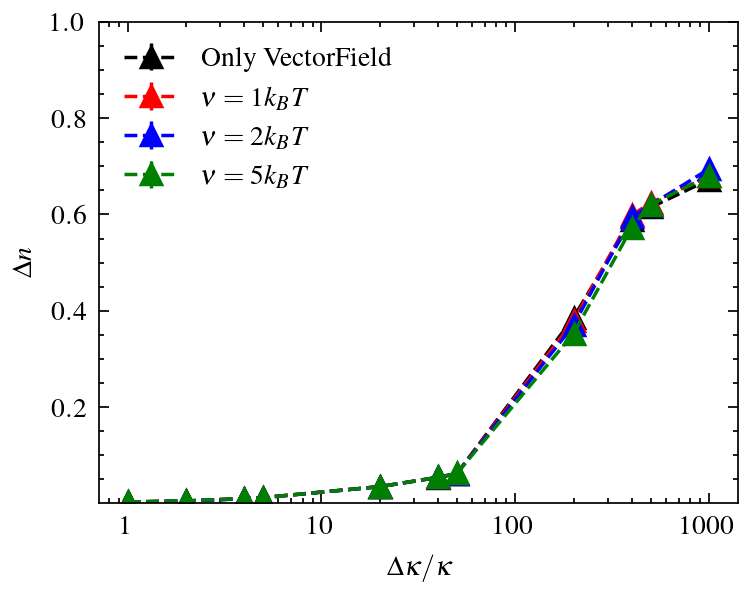

In [8]:
EPS=1
Simulation = base_dir + f"OnlyVectorField/EPS{EPS}"
mean, error = ProteinClustering(Simulation)
plt.errorbar(dK_list/kappa,mean,yerr=error,label=rf"Only VectorField",linestyle="dashed",marker="^")

#/lustre/astro/semygind/Data/MembraneInclusion/ProteinClustering/FromEquilibrium/ConstantVFF/VFF1/EPS1/RHO0.1/
VFF_list = [1,2,5]
for VFF in VFF_list:
    Simulation = base_dir + f"ConstantVFF/VFF{VFF}/EPS{EPS}"
    mean, error = ProteinClustering(Simulation)
    plt.errorbar(dK_list/kappa,mean,yerr=error,label=rf"$\nu={VFF} k_BT$",linestyle="dashed",marker="^")

from matplotlib.ticker import ScalarFormatter
plt.legend()
#plt.yscale('log')
plt.xscale('log')
plt.xlabel(r"$\Delta \kappa / \kappa$")
plt.ylabel(r"$\Delta n$")
plt.ylim(top=1,bottom=1e-3)
ax = plt.gca()
ax.xaxis.set_major_formatter(ScalarFormatter())
ax.yaxis.set_major_formatter(ScalarFormatter())
outdir = f"Plots/ProteinClustering"
os.makedirs(outdir, exist_ok=True)
plt.savefig(f"{outdir}/ConstantVFF.pdf")

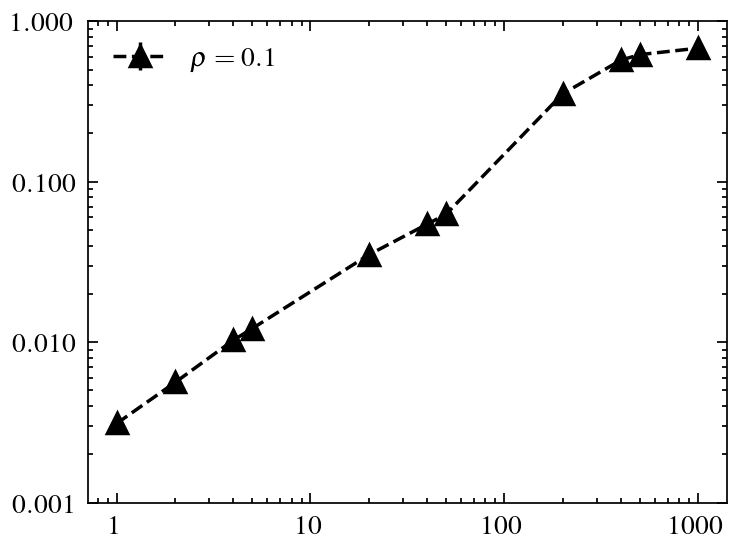

In [6]:
plt.errorbar(dK_list/kappa,mean,yerr=error,label=rf"$\rho={rho}$",linestyle="dashed",marker="^")
from matplotlib.ticker import ScalarFormatter
plt.legend()
plt.yscale('log')
plt.xscale('log')
plt.xlabel("")
plt.ylim(top=1,bottom=1e-3)
ax = plt.gca()
ax.xaxis.set_major_formatter(ScalarFormatter())
ax.yaxis.set_major_formatter(ScalarFormatter())
outdir = f"Plots/ProteinClustering"
os.makedirs(outdir, exist_ok=True)
plt.savefig(f"{outdir}/OnlyVectorField.pdf")